In [1]:
!pip -q install pandas numpy matplotlib seaborn scipy openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
n = 60

connectivity = np.random.normal(0.55, 0.12, n)
performance = 55 + (connectivity * 35) + np.random.normal(0, 6, n)

df = pd.DataFrame({
    "participant": range(1, n + 1),
    "connectivity_score": connectivity,
    "spatial_accuracy": performance
})

df.head()

,participant,connectivity_score,spatial_accuracy
0,1,0.609606,73.461154
1,2,0.533408,72.555336
2,3,0.627723,70.332282
3,4,0.732764,73.469486
4,5,0.521902,78.141711


In [4]:
r, p = pearsonr(df["connectivity_score"], df["spatial_accuracy"])

stats = pd.DataFrame({
    "correlation_r": [r],
    "p_value": [p]
})

stats

,correlation_r,p_value
0,0.600237,3.995955e-07


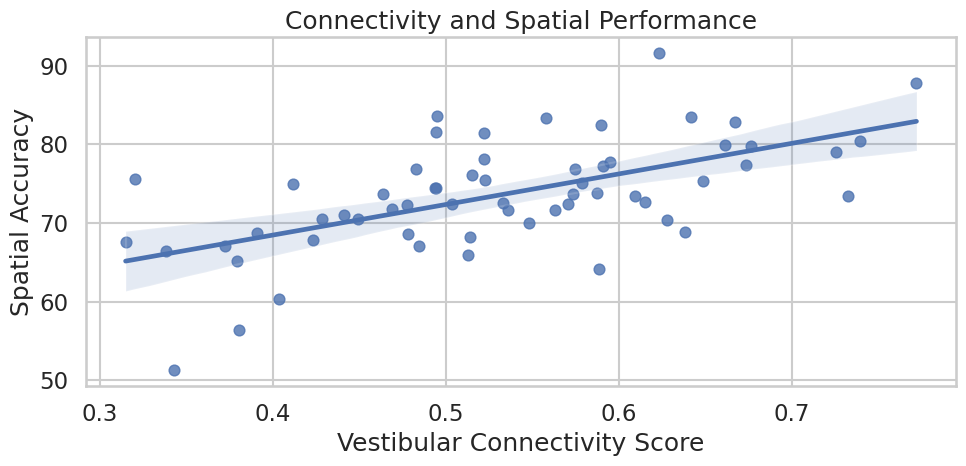

In [5]:
plt.figure(figsize=(10,5))

sns.regplot(
    data=df,
    x="connectivity_score",
    y="spatial_accuracy",
    scatter_kws={"s":60}
)

plt.xlabel("Vestibular Connectivity Score")
plt.ylabel("Spatial Accuracy")
plt.title("Connectivity and Spatial Performance")
plt.tight_layout()
plt.savefig("figures/03_connectivity_performance.png", dpi=300)
plt.show()

/tmp/ipykernel_2282/4145326524.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("quartile")["spatial_accuracy"]


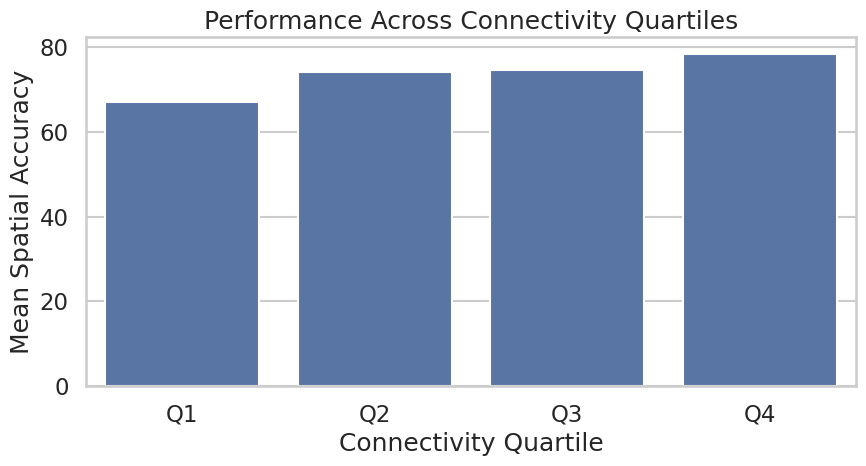

In [6]:
df["quartile"] = pd.qcut(df["connectivity_score"], 4, labels=["Q1","Q2","Q3","Q4"])

quartiles = (
    df.groupby("quartile")["spatial_accuracy"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9,5))

sns.barplot(
    data=quartiles,
    x="quartile",
    y="spatial_accuracy"
)

plt.xlabel("Connectivity Quartile")
plt.ylabel("Mean Spatial Accuracy")
plt.title("Performance Across Connectivity Quartiles")
plt.tight_layout()
plt.savefig("figures/03_quartile_performance.png", dpi=300)
plt.show()

In [7]:
df.to_csv("outputs/03_participant_spatial_association.csv", index=False)
stats.to_csv("outputs/03_correlation_stats.csv", index=False)

stats

,correlation_r,p_value
0,0.600237,3.995955e-07
